In [1]:

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
%matplotlib inline 
import seaborn as sns
sns.set_style('darkgrid')

In [2]:
df = pd.read_csv("fli.csv")
df.head()

,airline,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,SpiceJet,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,SpiceJet,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,AirAsia,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,Vistara,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,Vistara,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 999 entries, 0 to 998
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   airline           999 non-null    object 
 1   source_city       999 non-null    object 
 2   departure_time    999 non-null    object 
 3   stops             999 non-null    object 
 4   arrival_time      999 non-null    object 
 5   destination_city  999 non-null    object 
 6   class             999 non-null    object 
 7   duration          999 non-null    float64
 8   days_left         999 non-null    int64  
 9   price             999 non-null    int64  
dtypes: float64(1), int64(2), object(7)
memory usage: 78.2+ KB


In [4]:
df['airline'].value_counts()

airline
Vistara      342
Air_India    266
Indigo       153
GO_FIRST     139
SpiceJet      74
AirAsia       25
Name: count, dtype: int64

In [5]:
df['source_city'].value_counts()

source_city
Delhi    999
Name: count, dtype: int64

In [6]:
df['departure_time'].value_counts()

departure_time
Evening          301
Early_Morning    215
Morning          209
Afternoon        187
Night             87
Name: count, dtype: int64

In [7]:
df['destination_city'].value_counts()

destination_city
Mumbai    999
Name: count, dtype: int64

In [8]:
df['stops'].value_counts()

stops
one            713
zero           279
two_or_more      7
Name: count, dtype: int64

In [9]:
df['arrival_time'].value_counts()

arrival_time
Night            372
Morning          236
Afternoon        188
Evening          165
Early_Morning     35
Late_Night         3
Name: count, dtype: int64

In [10]:
df.describe()

,duration,days_left,price
count,999.000000,999.000000,999.000000
mean,10.464234,4.010010,10921.577578
std,7.989125,1.834839,4897.824494
min,2.000000,1.000000,5949.000000
25%,2.330000,2.000000,5955.000000
50%,8.250000,4.000000,10575.000000
75%,15.580000,6.000000,13410.000000
max,30.080000,7.000000,31260.000000


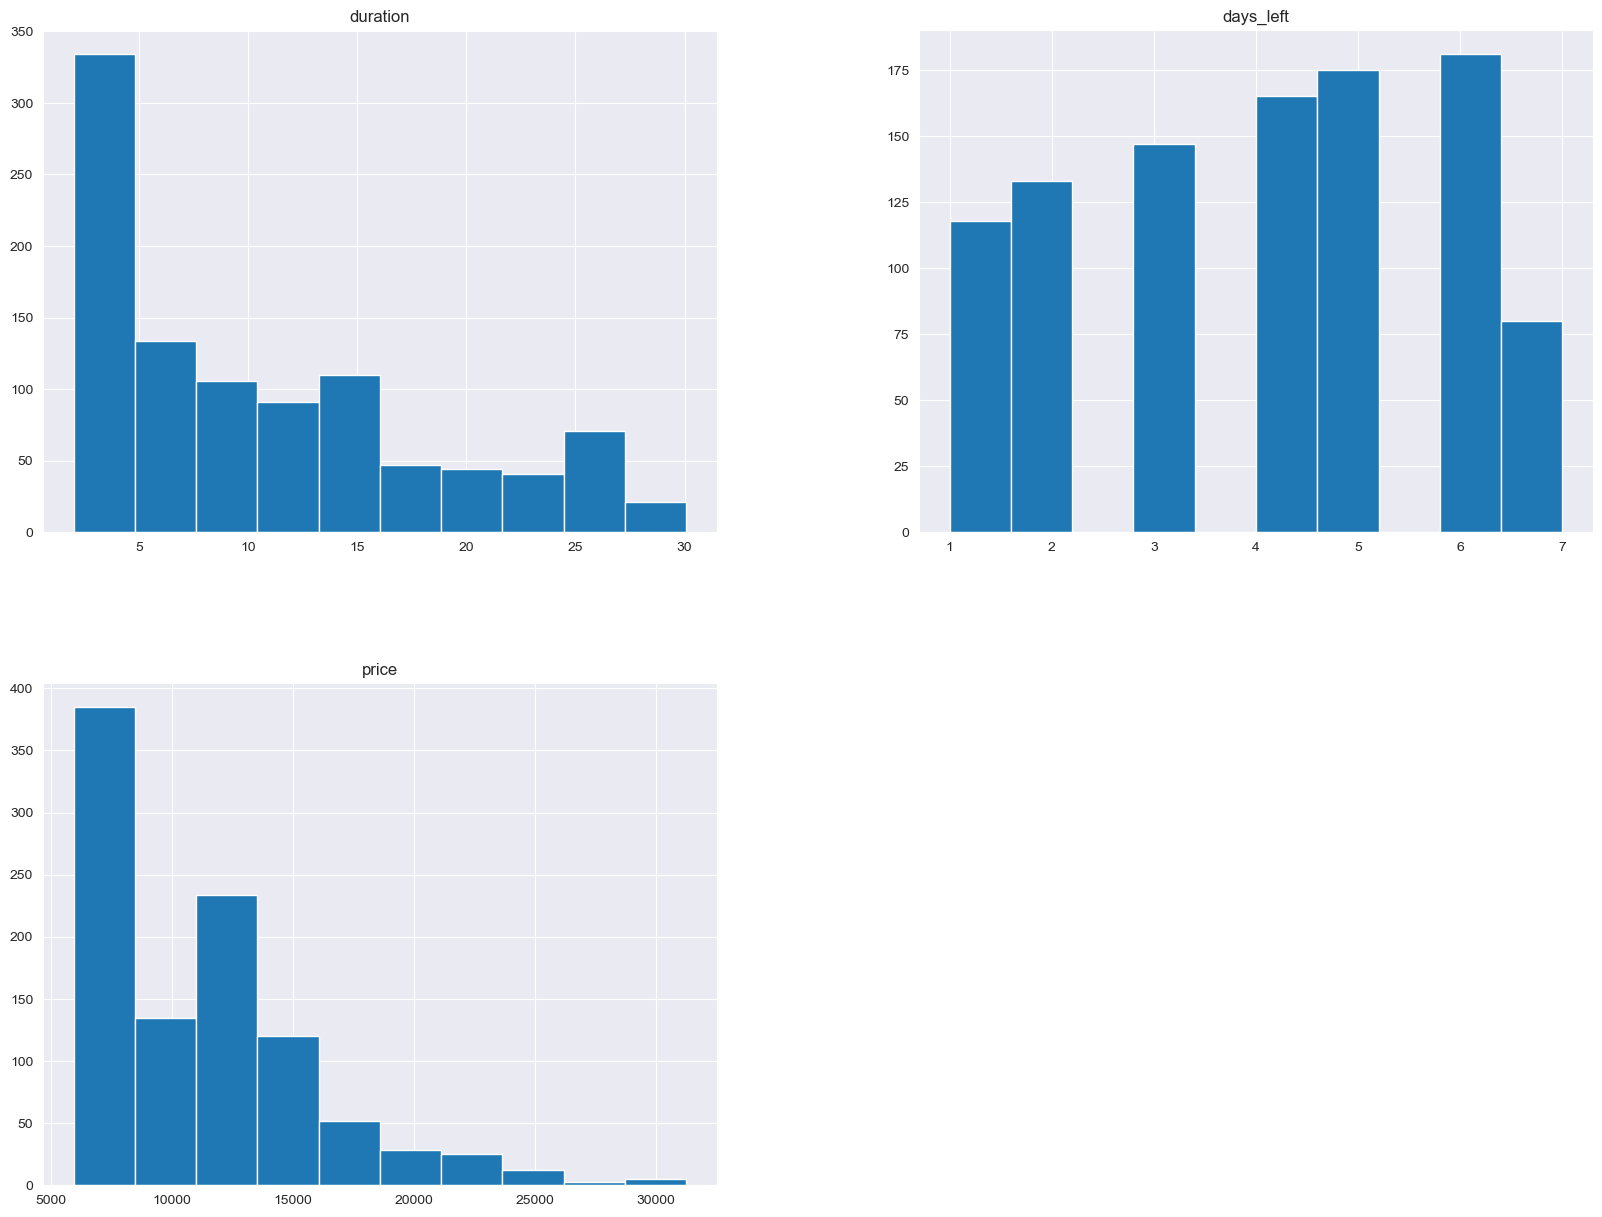

In [11]:
df.hist(figsize=(20, 15))
# plt.figure(figsize=[80, 80])
plt.show();

In [12]:
df = df.drop(["source_city", "destination_city"], axis=1)

In [13]:
df["stops"].value_counts()

stops
one            713
zero           279
two_or_more      7
Name: count, dtype: int64

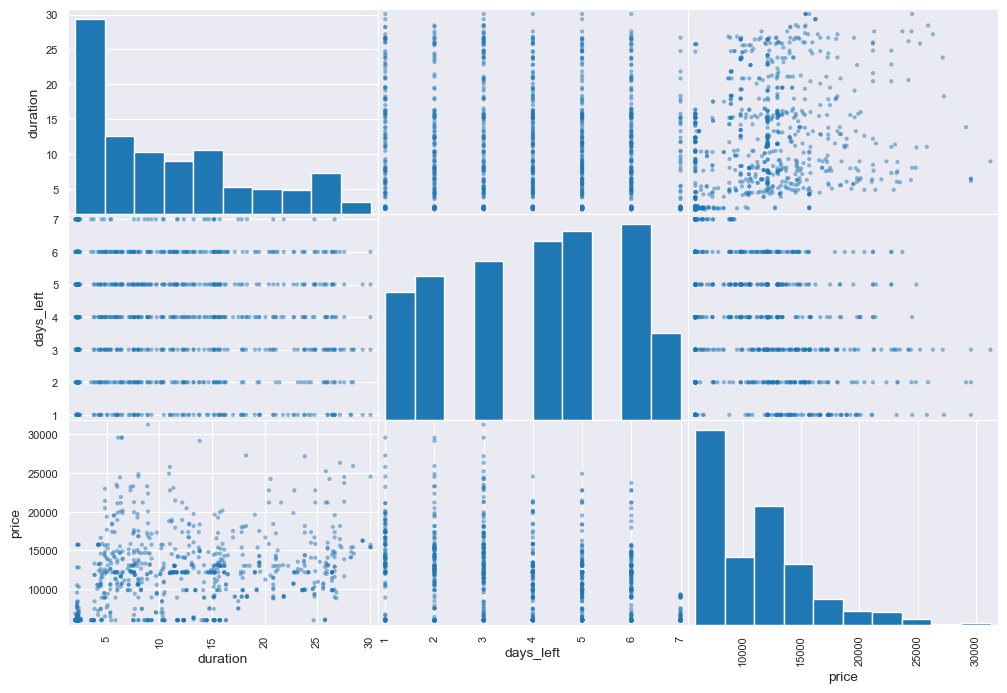

In [14]:
from pandas.plotting import scatter_matrix
attributes = ["stops", "class", "duration", "days_left", "price"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()

In [15]:
# corr_attr1 = df[attributes].corr
df.loc[:, ["duration","days_left"]]

,duration,days_left
0,2.17,1
1,2.33,1
2,2.17,1
3,2.25,1
4,2.33,1
...,...,...
994,15.17,7
995,17.83,7
996,20.83,7
997,10.42,7


In [16]:
corr_attr1 = df["duration"].corr(df.price)
corr_attr1

np.float64(0.43751861943547143)

In [17]:
correlation_coefficient = df['price'].corr(df['duration'])
print(f"\nCorrelation between column A and B: {correlation_coefficient}")



Correlation between column A and B: 0.4375186194354714


In [18]:
from sklearn.preprocessing import OneHotEncoder

le = OneHotEncoder()
df["stops"] = le.fit_transform(df["stops"])

ValueError: Expected a 2-dimensional container but got <class 'pandas.core.series.Series'> instead. Pass a DataFrame containing a single row (i.e. single sample) or a single column (i.e. single feature) instead.

In [ ]:
df["stops"]

In [ ]:
from sklearn.preprocessing import OneHotEncoder

my_label = OneHotEncoder()
df["class"] = my_label.fit_transform(df["class"])

In [ ]:
df.head()

In [ ]:
from pandas.plotting import scatter_matrix
attributes = ["stops", "class", "duration", "days_left", "price"]
scatter_matrix(df[attributes], figsize=(12, 8))
plt.show()

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class FeatureCreator(BaseEstimator, TransformerMixin):
    
    def __init__(self):
        pass
    
    def fit(self, X, y=None):
        return self
    
    def transform(self, X):
        X = X.copy()
        
        X["is_short_flight"] = (X["duration"] < 2).astype(int)
        X['duration_minutes'] = X['duration'] * 60

        return X

In [ ]:
df.head()

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])

In [ ]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ('encoder', OneHotEncoder())
])

In [ ]:
df.info()

In [ ]:
from sklearn.compose import ColumnTransformer

num_cols = ["stops", "class", "duration", "days_left"]
cat_cols = ["airline", "departure_time", "arrival_time"]

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [ ]:
from sklearn.pipeline import Pipeline

full_pipeline = Pipeline([
    ("feature_creator", FeatureCreator()),
    ("preprocessing", preprocessor)
])

In [ ]:
print(df.columns.tolist())

In [ ]:
X_processed = full_pipeline.fit_transform(df)

In [ ]:
target = "price"  
X = df.drop(target, axis=1)
y = df[target]

In [ ]:
def split_train_test(data, test_ratio):
    shuffled_indices = np.random.permutation(len(data))
    test_set_size = int(len(data)* test_ratio)
    test_indices = shuffled_indices[:test_set_size]
    train_indices =shuffled_indices[test_set_size:]
    return data.iloc[train_indices], data.iloc[test_indices]

In [ ]:
train_indices, test_indices = split_train_test(df, 0.2)
len(train_indices)


In [ ]:
len(test_indices)

In [ ]:
from sklearn.model_selection import train_test_split
train_set, test_set = train_test_split(df, test_size=0.2, random_state=42)

In [ ]:
len(train_set)


In [ ]:
len(test_set)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit 
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [ ]:
import pandas as pd

df['price_cat'] = pd.cut(
    df['price'],
    bins=[0, 5000, 10000, 20000, 40000, float("inf")],
    labels=[1,2,3,4,5]
)

In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

for train_index, test_index in split.split(df, df['price_cat']):
    strat_train_set = df.loc[train_index]
    strat_test_set = df.loc[test_index]

In [ ]:
strat_test_set['price'].value_counts()/len(strat_test_set)

In [ ]:
df2 = pd.DataFrame({
    "strat_train_set": strat_train_set["price"],
    "strat_test_set": strat_test_set["price"]
})

In [ ]:
y_train = strat_train_set["price"].copy()
X_train = strat_train_set.drop("price", axis=1)

In [ ]:
X_test = strat_test_set.drop("price", axis=1)
y_test = strat_test_set["price"].copy()

In [ ]:
df2 = pd.DataFrame(data = {
    'train_indicator' : train_indices['price'],
    'train_set' : train_set['price'],
    'strat_train_set' : strat_train_set['price'],

})
df2.head()

In [ ]:
df.price.mean()

In [ ]:
df2.describe()

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

In [ ]:
from sklearn.pipeline import Pipeline

full_model_pipeline = Pipeline([
    ("feature_creator", FeatureCreator()),
    ("preprocessor", preprocessor), 
    ("model", model)
])

In [ ]:
full_model_pipeline.fit(X_train, y_train)

In [ ]:
y_pred = full_model_pipeline.predict(X_test)

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
the_new = np.sqrt(mse)
print("MSE:", mse)
print("R2:", the_new)

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(full_model_pipeline, X_train, y_train, cv=5, scoring="neg_mean_squared_error")
_scores = np.sqrt(-scores)

In [ ]:
_scores

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.pipeline import Pipeline

tree_pipeline = Pipeline([
    ("feature_creator", FeatureCreator()), 
    ("preprocessor", preprocessor),       
    ("model", DecisionTreeRegressor(random_state=42))
])

tree_pipeline.fit(X_train, y_train)

y_pred = tree_pipeline.predict(X_test)

In [ ]:
tree_mse = mean_squared_error(y_test, y_pred)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

In [ ]:
scores = cross_val_score(tree_pipeline, X_train, y_train, 
                         scoring="neg_mean_squared_error", cv=10)
tree_rmse_scores = np.sqrt(-scores)


In [ ]:
tree_rmse_scores

In [ ]:
def display_scores(scores):
    print("Scores:" , scores )
    print("Mean:", scores.mean())
    print("Standard deviation: ", scores.std())

In [ ]:
display_scores(tree_rmse_scores)

In [ ]:
tree_mse = mean_squared_error(y_test, y_pred)
tree_rmse = np.sqrt(tree_mse)
tree_rmse

In [ ]:
X_train = pd.get_dummies(X_train)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
forest_reg = RandomForestRegressor()
forest_reg.fit(X_train, y_train)

In [ ]:
forest_reg_predict = forest_reg.predict(X_train)
forest_reg_mse = mean_squared_error(y_train, forest_reg_predict)
forest_reg_rmse = np.sqrt(forest_reg_mse)
forest_reg_rmse

In [ ]:
forest_scores = cross_val_score(forest_reg, X_train, y_train,  scoring="neg_mean_squared_error", cv=10)


In [ ]:
forest_rmse_scores = np.sqrt(-forest_scores)
display_scores(forest_rmse_scores)

In [ ]:
import joblib

In [ ]:
joblib.dump(forest_scores, "the_new.pkl" )

In [ ]:
forest_scored = joblib.load("the_new.pkl")

In [ ]:
forest_rmse_scores = np.sqrt(-forest_scored)
display_scores(forest_rmse_scores)

In [ ]:
from sklearn.model_selection import GridSearchCV
param_grid = [
    {'n_estimators': [3, 10, 30], 'max_features':[2,4,6,8]},
    {'bootstrap': [False], 'n_estimators': [3,10], 'max_features': [2, 3, 4]},
]
forest_reg = RandomForestRegressor()
grid_search = GridSearchCV(
    forest_reg, param_grid, cv=5, scoring='neg_mean_squared_error', return_train_score=True
)
grid_search.fit(X_train, y_train)

In [ ]:
grid_search.best_params_

In [ ]:
grid_search.best_estimator_

In [ ]:
cvres = grid_search.cv_results_
for mean_score, params in zip(cvres["mean_test_score"], cvres["params"]):
    print(np.sqrt(-mean_score), params)